In [16]:
import os
import numpy as np
import pandas as pd

# =========================
# 配置
# =========================
class Config:
    BASE_PATH = "/content/drive/MyDrive/AI Studio"
    TARGET_REGION = "PJME"
    DATA_FILES = [
        os.path.join(BASE_PATH, "AEP_hourly.csv"),
        os.path.join(BASE_PATH, "COMED_hourly.csv"),
        os.path.join(BASE_PATH, "DAYTON_hourly.csv"),
        os.path.join(BASE_PATH, "DEOK_hourly.csv"),
        os.path.join(BASE_PATH, "DOM_hourly.csv"),
        os.path.join(BASE_PATH, "DUQ_hourly.csv"),
        os.path.join(BASE_PATH, "EKPC_hourly.csv"),
        os.path.join(BASE_PATH, "FE_hourly.csv"),
        os.path.join(BASE_PATH, "NI_hourly.csv"),
        os.path.join(BASE_PATH, "pjm_hourly_est.csv"),
        os.path.join(BASE_PATH, "PJM_Load_hourly.csv"),
        os.path.join(BASE_PATH, "PJME_hourly.csv"),
        os.path.join(BASE_PATH, "PJMW_hourly.csv"),
    ]

# =========================
# 数据处理函数
# =========================
def load_and_process_data():
    print("Loading and merging multiple region files...")
    main_df = None
    loaded_regions = []

    for file_path in Config.DATA_FILES:
        if not os.path.exists(file_path):
            print(f"Warning: {file_path} not found. Skipping.")
            continue

        df = pd.read_csv(file_path)

        # 自动识别时间列
        dt_col = None
        for candidate in ['Datetime', 'datetime', 'Date', 'date', df.columns[0]]:
            if candidate in df.columns:
                dt_col = candidate
                break
        if dt_col is None:
            raise ValueError(f"No datetime-like column found in {file_path}")

        df = df.rename(columns={dt_col: 'Datetime'})
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df = df.set_index('Datetime')
        df = df.sort_index()
        df = df[~df.index.duplicated(keep='first')]

        # 自动识别数值列
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if not numeric_cols:
            print(f"Warning: no numeric columns found in {file_path}. Skipping.")
            continue

        # 优先选带 MW 的列，否则取第一个数值列
        col_name = next((c for c in numeric_cols if 'MW' in c or 'mw' in c), numeric_cols[0])

        # 从文件名提取区域名
        region_name = os.path.basename(file_path).split('_')[0].upper()

        # 重命名并只保留该列
        df = df.rename(columns={col_name: region_name})
        df = df[[region_name]]

        # 防止重复区域名导致 _x/_y
        if main_df is not None and region_name in main_df.columns:
            print(f"Warning: duplicated region name {region_name}, skipping duplicate file: {file_path}")
            continue

        # 外连接合并
        if main_df is None:
            main_df = df
        else:
            main_df = main_df.merge(df, left_index=True, right_index=True, how='outer')

        loaded_regions.append(region_name)

    if main_df is None or main_df.empty:
        raise ValueError("No data loaded. Check file paths and dataset availability.")

    # 排序
    main_df = main_df.sort_index()

    # 添加时间特征
    main_df['hour'] = main_df.index.hour
    main_df['day_of_week'] = main_df.index.dayofweek
    main_df['month'] = main_df.index.month
    main_df['day_of_year'] = main_df.index.dayofyear
    main_df['year'] = main_df.index.year

    # 缺失值处理
    main_df = main_df.interpolate(method='time', limit_direction='both')
    main_df = main_df.ffill().bfill()

    # 把目标列放到最前面
    cols = list(main_df.columns)
    target = Config.TARGET_REGION.upper()
    if target in cols:
        cols.insert(0, cols.pop(cols.index(target)))
        main_df = main_df[cols]
    else:
        raise ValueError(f"Target region {target} not found. Loaded regions: {loaded_regions}")

    print(f"Merged Data Shape: {main_df.shape}")
    print(f"Features: {list(main_df.columns)}")
    print(f"Time Range: {main_df.index.min()} to {main_df.index.max()}")

    return main_df

# =========================
# 执行处理并保存
# =========================
processed_df = load_and_process_data()

# 保存为 csv
output_path = os.path.join(Config.BASE_PATH, "merged_processed_power_load.csv")
processed_df.reset_index().to_csv(output_path, index=False)

print(f"\nSaved merged CSV to:\n{output_path}")
print(processed_df.head())

Loading and merging multiple region files...
Merged Data Shape: (178258, 17)
Features: ['PJME', 'AEP', 'COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'NI', 'PJM', 'PJMW', 'hour', 'day_of_week', 'month', 'day_of_year', 'year']
Time Range: 1998-04-01 01:00:00 to 2018-08-03 00:00:00

Saved merged CSV to:
/content/drive/MyDrive/AI Studio/merged_processed_power_load.csv
                        PJME      AEP   COMED  DAYTON    DEOK     DOM     DUQ  \
Datetime                                                                        
1998-04-01 01:00:00  30393.0  12379.0  9631.0  1621.0  2533.0  7190.0  1364.0   
1998-04-01 02:00:00  30393.0  12379.0  9631.0  1621.0  2533.0  7190.0  1364.0   
1998-04-01 03:00:00  30393.0  12379.0  9631.0  1621.0  2533.0  7190.0  1364.0   
1998-04-01 04:00:00  30393.0  12379.0  9631.0  1621.0  2533.0  7190.0  1364.0   
1998-04-01 05:00:00  30393.0  12379.0  9631.0  1621.0  2533.0  7190.0  1364.0   

                       EKPC   FE      NI     PJM    PJMW

## Original data

In [17]:
import pandas as pd
import os

BASE_PATH = "/content/drive/MyDrive/AI Studio"

DATA_FILES = [
    "AEP_hourly.csv",
    "COMED_hourly.csv",
    "DAYTON_hourly.csv",
    "DEOK_hourly.csv",
    "DOM_hourly.csv",
    "DUQ_hourly.csv",
    "EKPC_hourly.csv",
    "FE_hourly.csv",
    "NI_hourly.csv",
    "pjm_hourly_est.csv",
    "PJM_Load_hourly.csv",
    "PJME_hourly.csv",
    "PJMW_hourly.csv"
]

raw_data = {}
summary_list = []

for file in DATA_FILES:
    path = os.path.join(BASE_PATH, file)
    df = pd.read_csv(path)
    raw_data[file] = df

    dt_col = df.columns[0]
    val_col = df.columns[1]

    temp = df.copy()
    temp[dt_col] = pd.to_datetime(temp[dt_col], errors="coerce")

    summary_list.append({
        "File": file,
        "Rows": temp.shape[0],
        "Columns": temp.shape[1],
        "Start Time": temp[dt_col].min(),
        "End Time": temp[dt_col].max(),
        "Missing Datetime": temp[dt_col].isnull().sum(),
        "Missing Load": temp[val_col].isnull().sum(),
        "Duplicate Datetime": temp.duplicated(subset=dt_col).sum()
    })

summary_df = pd.DataFrame(summary_list)
summary_df

,File,Rows,Columns,Start Time,End Time,Missing Datetime,Missing Load,Duplicate Datetime
0,AEP_hourly.csv,121273,2,2004-10-01 01:00:00,2018-08-03,0,0,4
1,COMED_hourly.csv,66497,2,2011-01-01 01:00:00,2018-08-03,0,0,4
2,DAYTON_hourly.csv,121275,2,2004-10-01 01:00:00,2018-08-03,0,0,4
3,DEOK_hourly.csv,57739,2,2012-01-01 01:00:00,2018-08-03,0,0,4
4,DOM_hourly.csv,116189,2,2005-05-01 01:00:00,2018-08-03,0,0,4
5,DUQ_hourly.csv,119068,2,2005-01-01 01:00:00,2018-08-03,0,0,4
6,EKPC_hourly.csv,45334,2,2013-06-01 01:00:00,2018-08-03,0,0,4
7,FE_hourly.csv,62874,2,2011-06-01 01:00:00,2018-08-03,0,0,4
8,NI_hourly.csv,58450,2,2004-05-01 01:00:00,2011-01-01,0,0,0
9,pjm_hourly_est.csv,178262,13,1998-04-01 01:00:00,2018-08-03,0,56989,4


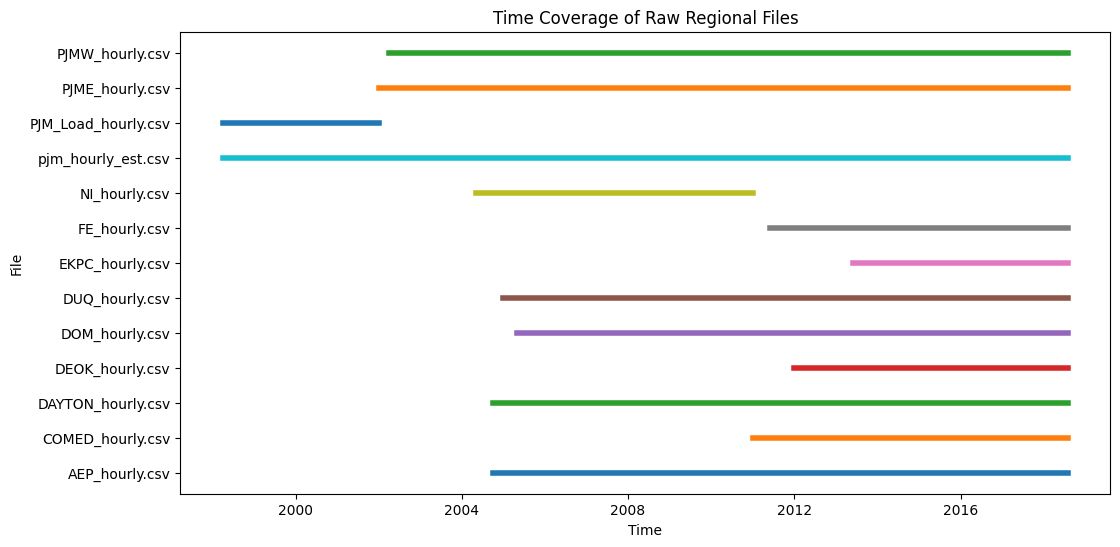

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, row in summary_df.iterrows():
    plt.plot([row["Start Time"], row["End Time"]], [i, i], linewidth=4)

plt.yticks(range(len(summary_df)), summary_df["File"])
plt.xlabel("Time")
plt.ylabel("File")
plt.title("Time Coverage of Raw Regional Files")
plt.show()

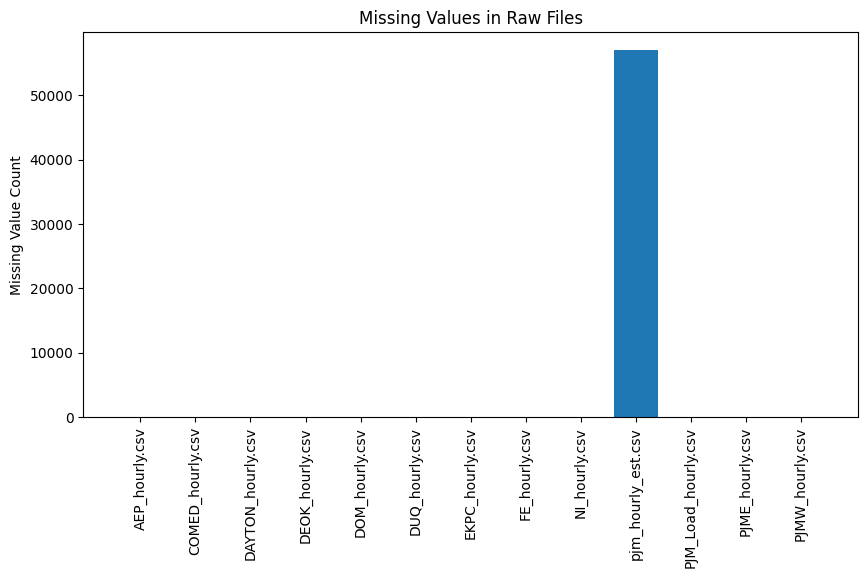

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(summary_df["File"], summary_df["Missing Load"])
plt.xticks(rotation=90)
plt.ylabel("Missing Value Count")
plt.title("Missing Values in Raw Files")
plt.show()

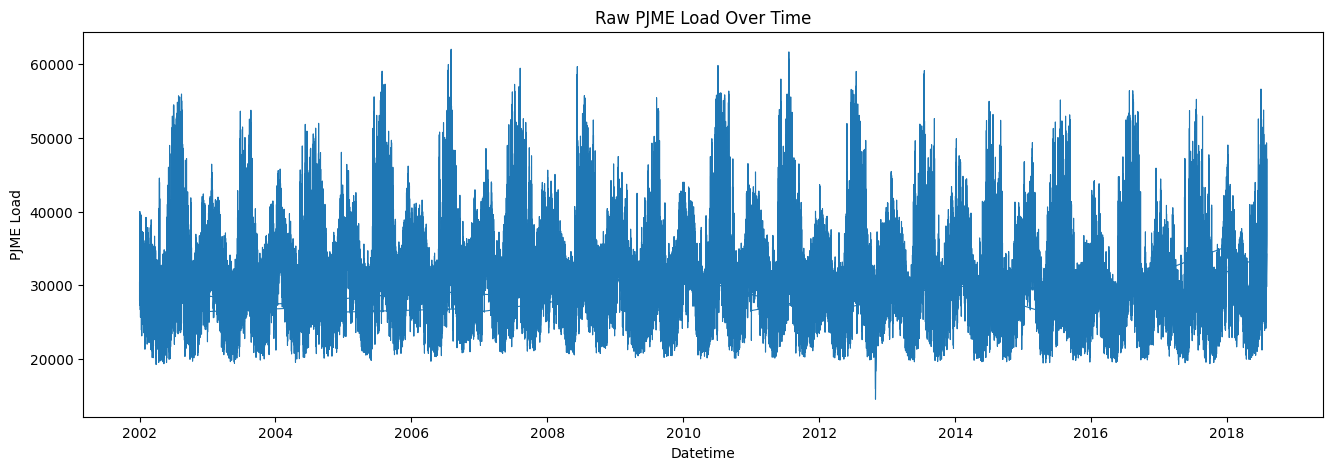

In [20]:
pjme_raw = raw_data["PJME_hourly.csv"].copy()
pjme_raw.iloc[:, 0] = pd.to_datetime(pjme_raw.iloc[:, 0], errors="coerce")

plt.figure(figsize=(16, 5))
plt.plot(pjme_raw.iloc[:, 0], pjme_raw.iloc[:, 1], linewidth=0.8)
plt.xlabel("Datetime")
plt.ylabel("PJME Load")
plt.title("Raw PJME Load Over Time")
plt.show()

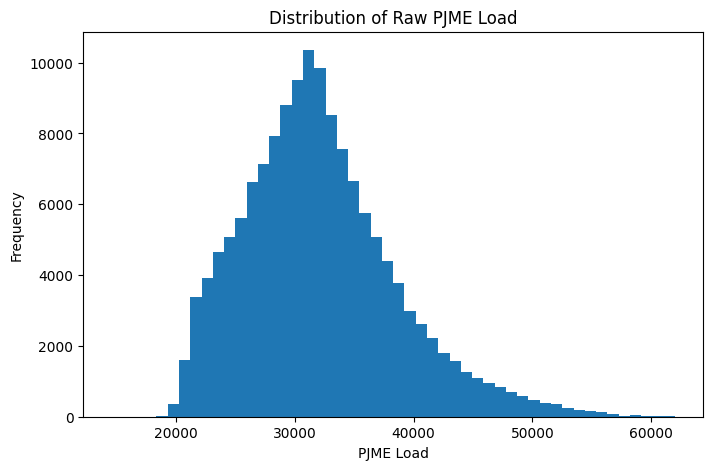

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(pjme_raw.iloc[:, 1].dropna(), bins=50)
plt.xlabel("PJME Load")
plt.ylabel("Frequency")
plt.title("Distribution of Raw PJME Load")
plt.show()

## Merge data

In [22]:
df = pd.read_csv("/content/drive/MyDrive/AI Studio/merged_processed_power_load.csv")
df["Datetime"] = pd.to_datetime(df["Datetime"])
print(df.columns.tolist())

['Datetime', 'PJME', 'AEP', 'COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'NI', 'PJM', 'PJMW', 'hour', 'day_of_week', 'month', 'day_of_year', 'year']


In [23]:
basic_info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values
})
basic_info

,Column,Data Type,Missing Values
0,Datetime,datetime64[ns],0
1,PJME,float64,0
2,AEP,float64,0
3,COMED,float64,0
4,DAYTON,float64,0
5,DEOK,float64,0
6,DOM,float64,0
7,DUQ,float64,0
8,EKPC,float64,0
9,FE,float64,0


In [24]:
desc_table = df.describe().T
desc_table

,count,mean,min,25%,50%,75%,max,std
Datetime,178258,2008-06-01 14:13:20.567716096,1998-04-01 01:00:00,2003-05-02 08:15:00,2008-06-01 14:30:00,2013-07-02 21:45:00,2018-08-03 00:00:00,NaN
PJME,178258.0,31769.094997,14544.0,28578.0,30393.0,34460.0,62009.0,5873.638832
AEP,178258.0,14502.008255,9581.0,12379.0,13745.0,16185.0,25695.0,2585.762768
COMED,178258.0,10298.455531,7237.0,9631.0,9631.0,10275.0,23753.0,1651.978388
DAYTON,178258.0,1904.602896,982.0,1621.0,1768.0,2138.0,3746.0,378.257415
DEOK,178258.0,2718.311907,907.0,2533.0,2533.0,2650.0,5445.0,433.844281
DOM,178258.0,9640.241493,1253.0,7190.0,9216.0,11249.0,21651.0,2646.784499
DUQ,178258.0,1560.931016,1014.0,1364.0,1446.0,1716.0,3054.0,283.002178
EKPC,178258.0,1241.843025,514.0,1166.0,1166.0,1166.0,3490.0,231.015473
FE,178258.0,2748.273003,0.0,0.0,0.0,6973.0,14032.0,3806.234804


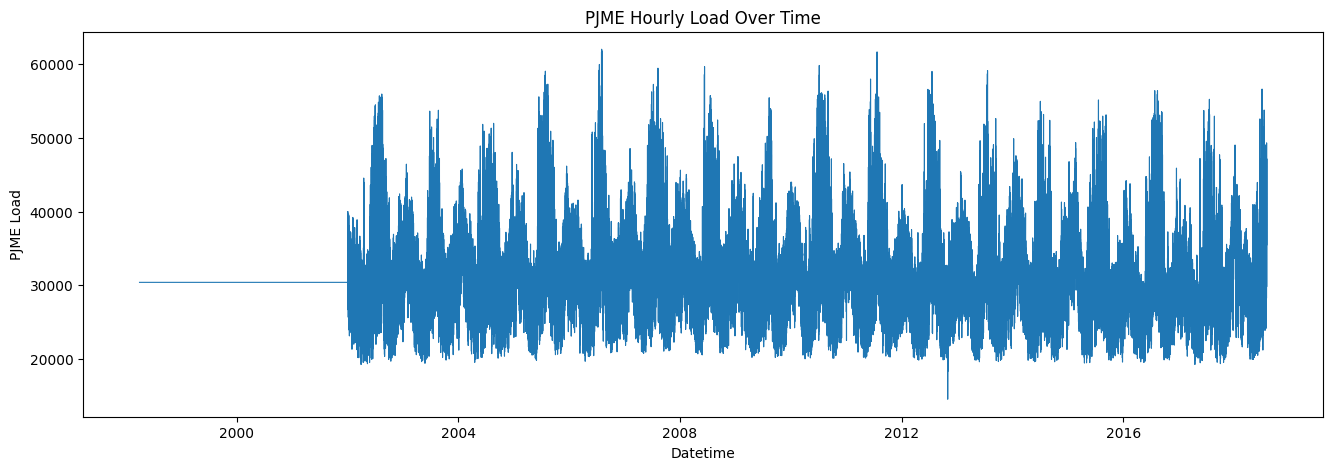

In [25]:
plt.figure(figsize=(16, 5))
plt.plot(df["Datetime"], df["PJME"], linewidth=0.8)
plt.xlabel("Datetime")
plt.ylabel("PJME Load")
plt.title("PJME Hourly Load Over Time")
plt.show()

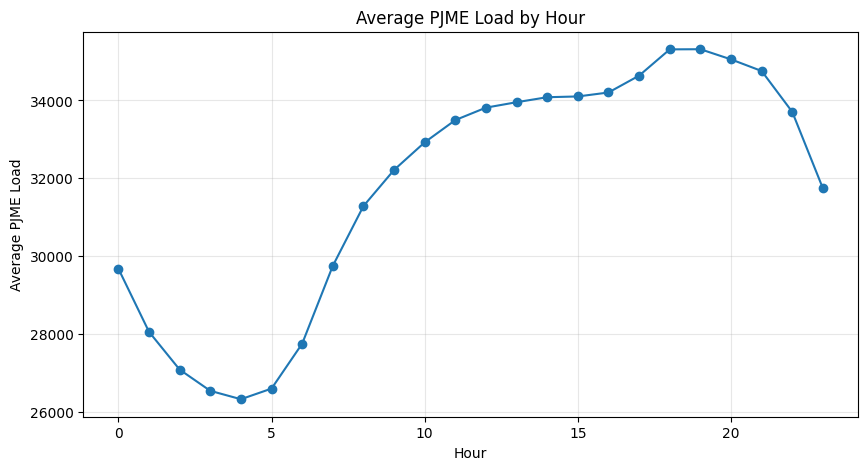

In [26]:
hourly_mean = df.groupby("hour")["PJME"].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_mean.index, hourly_mean.values, marker="o")
plt.xlabel("Hour")
plt.ylabel("Average PJME Load")
plt.title("Average PJME Load by Hour")
plt.grid(True, alpha=0.3)
plt.show()

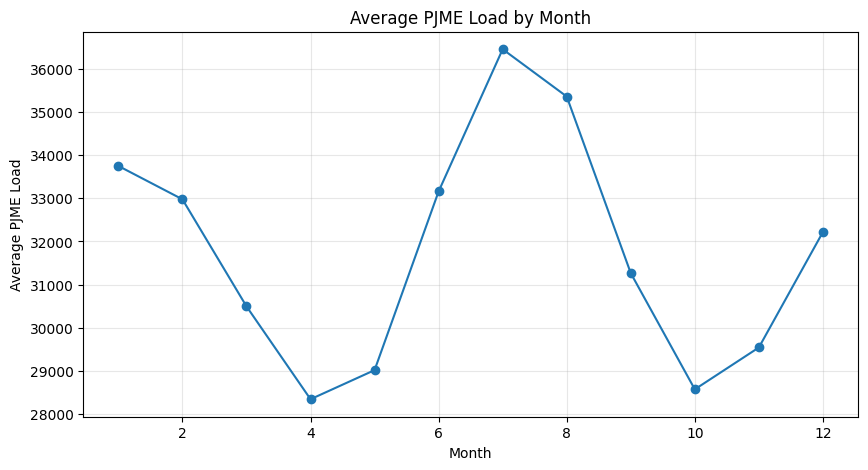

In [27]:
monthly_mean = df.groupby("month")["PJME"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_mean.index, monthly_mean.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average PJME Load")
plt.title("Average PJME Load by Month")
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
exclude_cols = ["Datetime", "hour", "day_of_week", "month", "day_of_year", "year"]
region_cols = [col for col in df.columns if col not in exclude_cols]

print("region_cols =", region_cols)

# 自动找 PJME 列
pjme_col = [c for c in region_cols if "PJME" in c.upper()][0]
print("PJME column =", pjme_col)

corr = df[region_cols].corr()
pjme_corr_table = corr[[pjme_col]].sort_values(by=pjme_col, ascending=False)
pjme_corr_table

region_cols = ['PJME', 'AEP', 'COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'NI', 'PJM', 'PJMW']
PJME column = PJME


,PJME
PJME,1.000000
PJMW,0.814840
PJM,0.814840
DUQ,0.776487
DAYTON,0.733380
AEP,0.704497
DOM,0.672031
NI,0.511355
COMED,0.460434
DEOK,0.409567


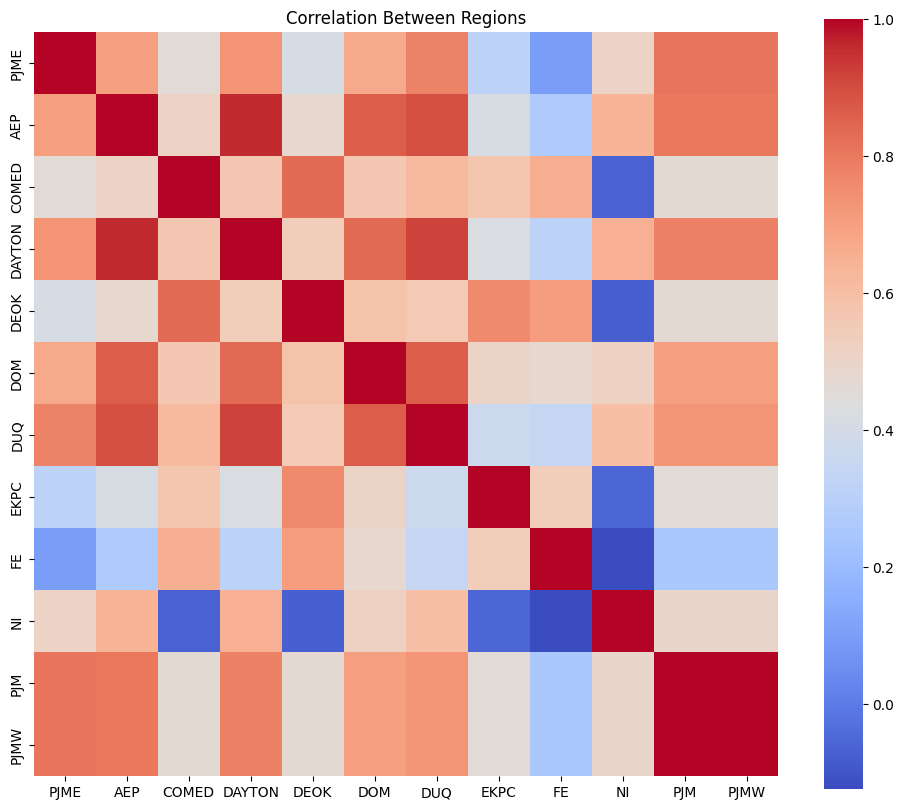

In [41]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", annot=False, square=True)
plt.title("Correlation Between Regions")
plt.show()

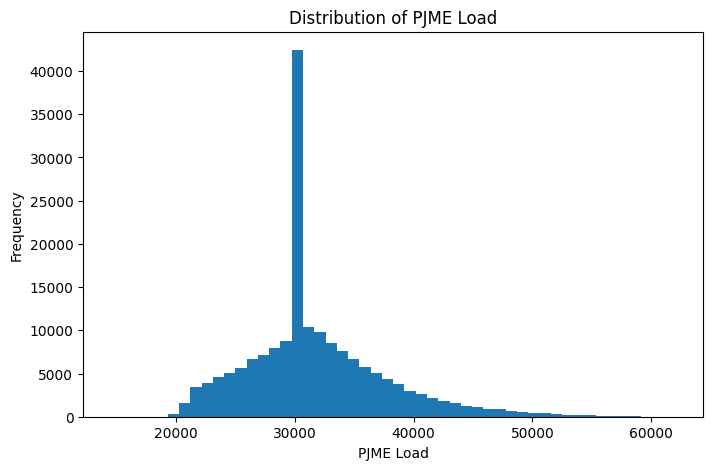

In [43]:
plt.figure(figsize=(8, 5))
plt.hist(df["PJME"], bins=50)
plt.xlabel("PJME Load")
plt.ylabel("Frequency")
plt.title("Distribution of PJME Load")
plt.show()

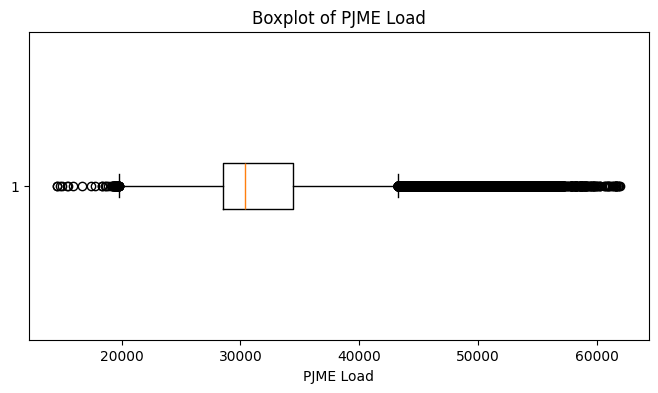

In [44]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["PJME"].dropna(), vert=False)
plt.xlabel("PJME Load")
plt.title("Boxplot of PJME Load")
plt.show()

In [36]:
exclude_cols = ["Datetime", "hour", "day_of_week", "month", "day_of_year", "year"]
region_cols = [col for col in df.columns if col not in exclude_cols]

print(region_cols)

['PJME', 'AEP', 'COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'NI', 'PJM', 'PJMW']


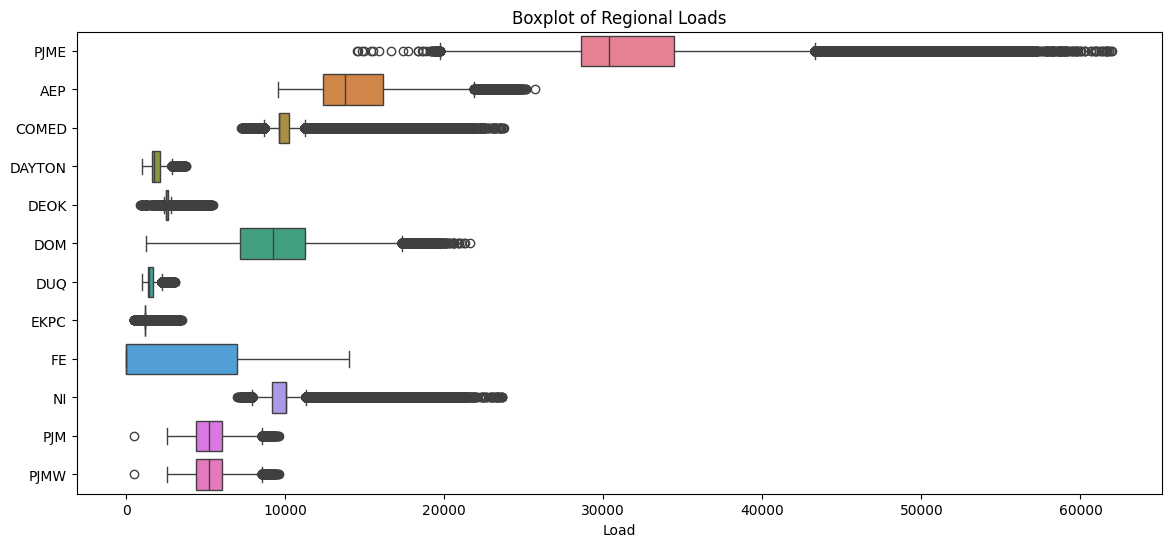

In [37]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[region_cols], orient="h")
plt.title("Boxplot of Regional Loads")
plt.xlabel("Load")
plt.show()

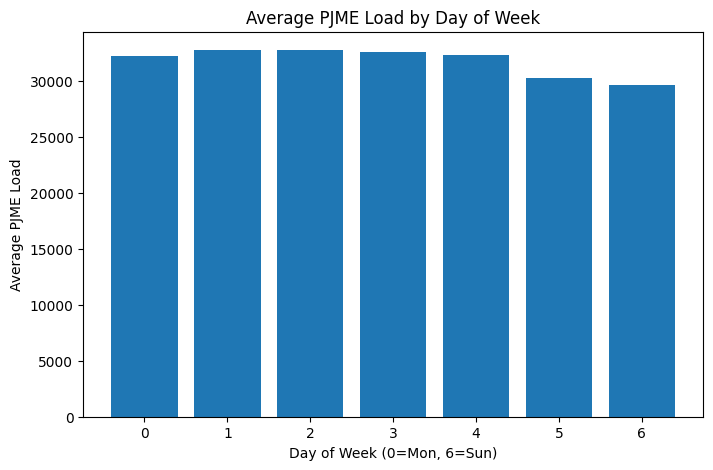

In [34]:
weekday_mean = df.groupby("day_of_week")["PJME"].mean()

plt.figure(figsize=(8, 5))
plt.bar(weekday_mean.index, weekday_mean.values)
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Average PJME Load")
plt.title("Average PJME Load by Day of Week")
plt.show()

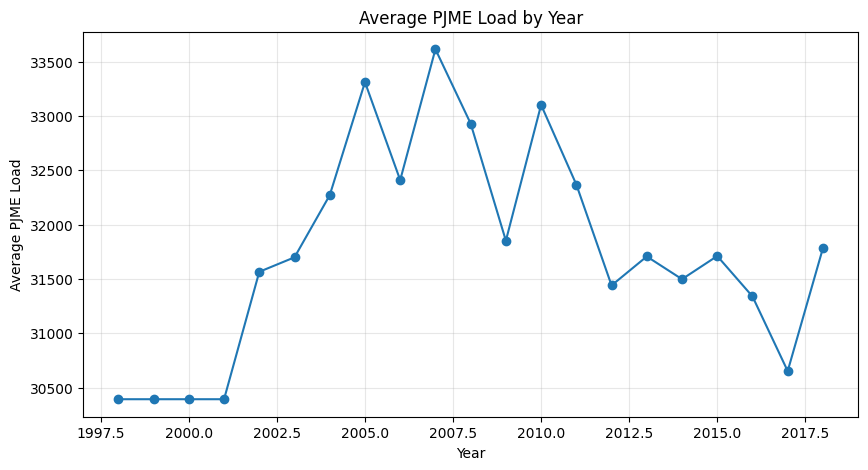

In [35]:
yearly_mean = df.groupby("year")["PJME"].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly_mean.index, yearly_mean.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Average PJME Load")
plt.title("Average PJME Load by Year")
plt.grid(True, alpha=0.3)
plt.show()